# 🩺 Disease Prediction using Symptoms

### Author
**Karthik Sri Vardhan**

---

## 📌 Project Overview

This project predicts diseases based on patient symptoms using Machine Learning. It processes symptom data, trains a classification model, and provides disease predictions to support early diagnosis.

---

## 🎯 Objective

- Predict diseases from user symptoms.
- Build an accurate Machine Learning classification model.
- Demonstrate an end-to-end healthcare prediction workflow.

## 📚 Technologies Used

- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn
- Joblib

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import joblib

## 📂 Dataset

The project uses two datasets:

 - **Training.csv** - Used to train the Machine Learning model.
 - **Testing.csv** - Used to evaluate model performance.

The dataset contains symptoms as input features and diseases as target labels.

train = pd.read_csv("Training.csv")
test = pd.read_csv("Testing.csv")

In [3]:
train.head(5)

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis,Unnamed: 133
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN


In [5]:
train.tail()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis,Unnamed: 133
4915,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,(vertigo) Paroymsal Positional Vertigo,NaN
4916,0,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,Acne,NaN
4917,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Urinary tract infection,NaN
4918,0,1,0,0,0,0,1,0,0,0,...,0,1,1,1,1,0,0,0,Psoriasis,NaN
4919,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,1,Impetigo,NaN


In [7]:
train.shape

(4920, 134)

In [8]:
train.columns

Index(['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing',
       'shivering', 'chills', 'joint_pain', 'stomach_pain', 'acidity',
       'ulcers_on_tongue',
       ...
       'scurring', 'skin_peeling', 'silver_like_dusting',
       'small_dents_in_nails', 'inflammatory_nails', 'blister',
       'red_sore_around_nose', 'yellow_crust_ooze', 'prognosis',
       'Unnamed: 133'],
      dtype='object', length=134)

In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Columns: 134 entries, itching to Unnamed: 133
dtypes: float64(1), int64(132), object(1)
memory usage: 5.0+ MB


In [10]:
train.describe()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,Unnamed: 133
count,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,...,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,0.0
mean,0.137805,0.159756,0.021951,0.045122,0.021951,0.162195,0.139024,0.045122,0.045122,0.021951,...,0.021951,0.021951,0.023171,0.023171,0.023171,0.023171,0.023171,0.023171,0.023171,NaN
std,0.344730,0.366417,0.146539,0.207593,0.146539,0.368667,0.346007,0.207593,0.207593,0.146539,...,0.146539,0.146539,0.150461,0.150461,0.150461,0.150461,0.150461,0.150461,0.150461,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN


## 🧹 Data Preprocessing

The following preprocessing steps are performed:

- Load datasets
- Remove unnecessary columns
- Separate features and target
- Encode disease labels
- Prepare data for model training

In [11]:
train = train.drop(columns=["Unnamed: 133"], errors="ignore")

In [12]:
train.shape

(4920, 133)

In [13]:
train.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


In [14]:
train.isnull().sum()

itching                 0
skin_rash               0
nodal_skin_eruptions    0
continuous_sneezing     0
shivering               0
                       ..
inflammatory_nails      0
blister                 0
red_sore_around_nose    0
yellow_crust_ooze       0
prognosis               0
Length: 133, dtype: int64

In [15]:
train.isnull().sum().sum()

np.int64(0)

In [16]:
train["prognosis"].unique()

array(['Fungal infection', 'Allergy', 'GERD', 'Chronic cholestasis',
       'Drug Reaction', 'Peptic ulcer diseae', 'AIDS', 'Diabetes ',
       'Gastroenteritis', 'Bronchial Asthma', 'Hypertension ', 'Migraine',
       'Cervical spondylosis', 'Paralysis (brain hemorrhage)', 'Jaundice',
       'Malaria', 'Chicken pox', 'Dengue', 'Typhoid', 'hepatitis A',
       'Hepatitis B', 'Hepatitis C', 'Hepatitis D', 'Hepatitis E',
       'Alcoholic hepatitis', 'Tuberculosis', 'Common Cold', 'Pneumonia',
       'Dimorphic hemmorhoids(piles)', 'Heart attack', 'Varicose veins',
       'Hypothyroidism', 'Hyperthyroidism', 'Hypoglycemia',
       'Osteoarthristis', 'Arthritis',
       '(vertigo) Paroymsal  Positional Vertigo', 'Acne',
       'Urinary tract infection', 'Psoriasis', 'Impetigo'], dtype=object)

In [17]:
train["prognosis"].value_counts()

prognosis
Fungal infection                           120
Hepatitis C                                120
Hepatitis E                                120
Alcoholic hepatitis                        120
Tuberculosis                               120
Common Cold                                120
Pneumonia                                  120
Dimorphic hemmorhoids(piles)               120
Heart attack                               120
Varicose veins                             120
Hypothyroidism                             120
Hyperthyroidism                            120
Hypoglycemia                               120
Osteoarthristis                            120
Arthritis                                  120
(vertigo) Paroymsal  Positional Vertigo    120
Acne                                       120
Urinary tract infection                    120
Psoriasis                                  120
Hepatitis D                                120
Hepatitis B                                120
All

In [18]:
# Features
X_train = train.drop("prognosis", axis=1)

# Target
y_train = train["prognosis"]

# Testing Features
X_test = test.drop("prognosis", axis=1)

# Testing Target
y_test = test["prognosis"]

In [19]:
print("Training Features:", X_train.shape)
print("Training Target:", y_train.shape)

print("Testing Features:", X_test.shape)
print("Testing Target:", y_test.shape)

Training Features: (4920, 132)
Training Target: (4920,)
Testing Features: (42, 132)
Testing Target: (42,)


## 🤖 Model Training

A Machine Learning classification model is trained using the processed symptom dataset.

The model learns relationships between symptoms and diseases to make accurate predictions.

In [20]:
model = DecisionTreeClassifier(random_state=42)

In [21]:
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [22]:
y_pred = model.predict(X_test)

## 📊 Model Evaluation

The trained model is evaluated on unseen testing data to measure prediction accuracy and overall performance.

In [23]:
accuracy = model.score(X_test, y_test)

print("Accuracy:", accuracy)

Accuracy: 0.9761904761904762


C:\Users\Karthik\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\Karthik\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


In [24]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9761904761904762


C:\Users\Karthik\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\Karthik\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


In [25]:
results = pd.DataFrame({
    "Actual Disease": y_test,
    "Predicted Disease": y_pred
})

results.head(10)

,Actual Disease,Predicted Disease
0,Fungal infection,Fungal infection
1,Allergy,Allergy
2,GERD,GERD
3,Chronic cholestasis,Chronic cholestasis
4,Drug Reaction,Drug Reaction
5,Peptic ulcer diseae,Peptic ulcer diseae
6,AIDS,AIDS
7,Diabetes,Diabetes
8,Gastroenteritis,Gastroenteritis
9,Bronchial Asthma,Bronchial Asthma


C:\Users\Karthik\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\Karthik\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
C:\Users\Karthik\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
C:\Users\Karthik\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique 

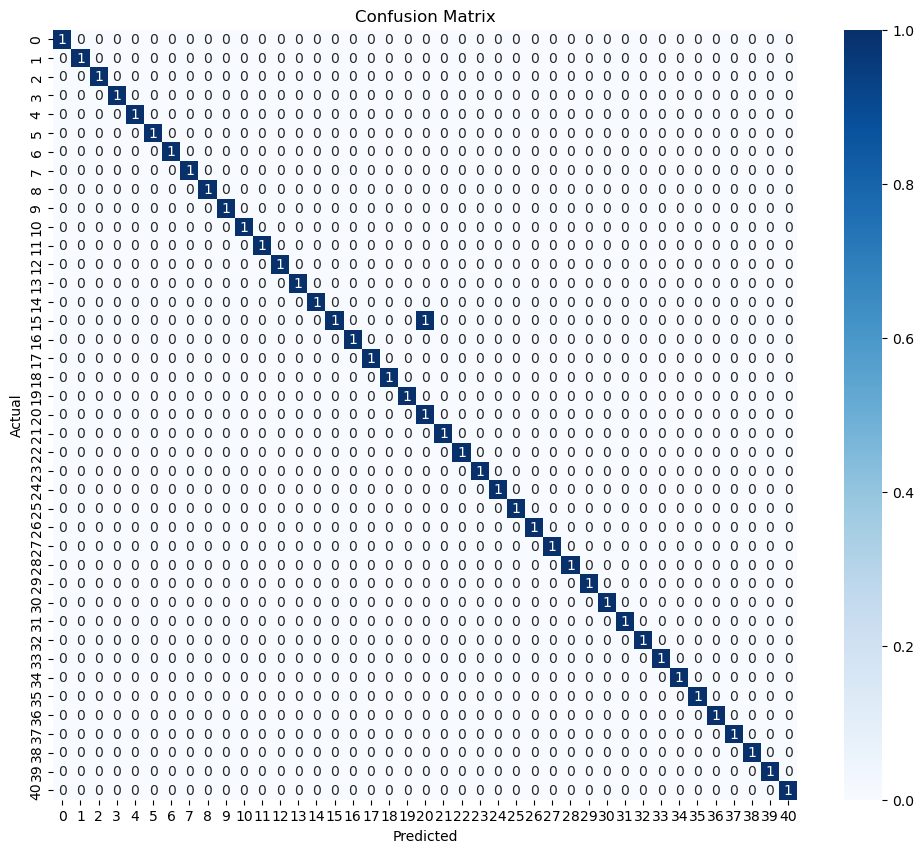

In [26]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                            Common Cold       1.00      1.00      1.00         1
                           

C:\Users\Karthik\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\Karthik\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
C:\Users\Karthik\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
C:\Users\Karthik\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique 

In [28]:
feature_importance = pd.DataFrame({
    "Symptom": X_train.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Symptom,Importance
25,high_fever,0.050272
97,muscle_pain,0.025000
71,enlarged_thyroid,0.025000
48,malaise,0.025000
41,mild_fever,0.025000
104,increased_appetite,0.025000
111,receiving_blood_transfusion,0.025000
36,pain_behind_the_eyes,0.025000
113,coma,0.025000
118,blood_in_sputum,0.025000


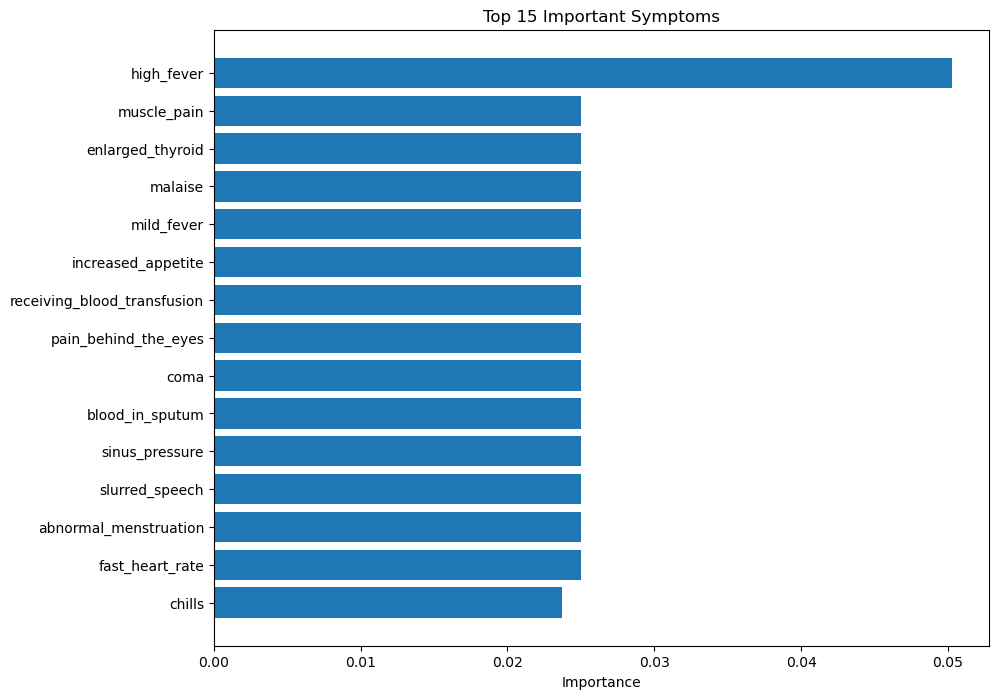

In [29]:
plt.figure(figsize=(10,8))

plt.barh(
    feature_importance["Symptom"][:15],
    feature_importance["Importance"][:15]
)

plt.title("Top 15 Important Symptoms")
plt.xlabel("Importance")
plt.gca().invert_yaxis()

plt.show()

In [32]:
import joblib

joblib.dump(model, "Disease-Prediction-Using-Symptoms/model.pkl")

['Disease-Prediction-Using-Symptoms/model.pkl']

In [33]:
loaded_model = joblib.load("Disease-Prediction-Using-Symptoms/model.pkl")

In [38]:
sample = X_train.iloc[[36]]

prediction = loaded_model.predict(sample)

print("Predicted Disease:", prediction[0])

Predicted Disease: Chronic cholestasis


## 🔍 Disease Prediction

Users can enter symptoms, and the trained model predicts the most probable disease based on the learned patterns.

In [43]:
# Get all symptoms from the training data
symptoms = X_train.columns.tolist()

# Create a dictionary with all symptoms set to 0
user_input = dict.fromkeys(symptoms, 0)

# Ask user for number of symptoms
n = int(input("How many symptoms do you have? "))

print("\nAvailable symptoms examples:")
print(", ".join(symptoms[:20]), "...\n")

# Ask user to enter symptoms
for i in range(n):
    symptom = input(f"Enter symptom {i+1}: ").strip().lower().replace(" ", "_")

    if symptom in user_input:
        user_input[symptom] = 1
    else:
        print(f"'{symptom}' is not found in the dataset. Ignored.")

# Convert to DataFrame
user_df = pd.DataFrame([user_input])

# Predict disease
prediction = loaded_model.predict(user_df)

print("\n==============================")
print("Predicted Disease:", prediction[0])
print("==============================")

How many symptoms do you have?  3



Available symptoms examples:
itching, skin_rash, nodal_skin_eruptions, continuous_sneezing, shivering, chills, joint_pain, stomach_pain, acidity, ulcers_on_tongue, muscle_wasting, vomiting, burning_micturition, spotting_ urination, fatigue, weight_gain, anxiety, cold_hands_and_feets, mood_swings, weight_loss ...



Enter symptom 1:  itching
Enter symptom 2:  fatigue
Enter symptom 3:  anxity


'anxity' is not found in the dataset. Ignored.

Predicted Disease: Heart attack


In [45]:
# ================================
# Disease Prediction - User Input
# ================================

import pandas as pd
import joblib

# Load the saved model
loaded_model = joblib.load("Disease-Prediction-Using-Symptoms/model.pkl")

# Get all symptom names
symptoms = X_train.columns.tolist()

# Display all symptoms with numbers
print("\n========== AVAILABLE SYMPTOMS ==========\n")

for i, symptom in enumerate(symptoms, start=1):
    print(f"{i}. {symptom.replace('_', ' ').title()}")

print("\n========================================\n")

# Create dictionary with all symptoms = 0
user_input = dict.fromkeys(symptoms, 0)

# Ask number of symptoms
n = int(input("How many symptoms do you have? "))

print()

# Ask symptom numbers
for i in range(n):

    while True:

        try:
            choice = int(input(f"Enter symptom number {i+1}: "))

            if 1 <= choice <= len(symptoms):
                symptom = symptoms[choice - 1]
                user_input[symptom] = 1
                break
            else:
                print("Invalid number. Please enter a number from the list.")

        except ValueError:
            print("Please enter a valid integer.")

# Convert dictionary into DataFrame
user_df = pd.DataFrame([user_input])

# Predict disease
prediction = loaded_model.predict(user_df)

print("\n=====================================")
print("Predicted Disease :", prediction[0])
print("=====================================")


========== AVAILABLE SYMPTOMS ==========

1. Itching
2. Skin Rash
3. Nodal Skin Eruptions
4. Continuous Sneezing
5. Shivering
6. Chills
7. Joint Pain
8. Stomach Pain
9. Acidity
10. Ulcers On Tongue
11. Muscle Wasting
12. Vomiting
13. Burning Micturition
14. Spotting  Urination
15. Fatigue
16. Weight Gain
17. Anxiety
18. Cold Hands And Feets
19. Mood Swings
20. Weight Loss
21. Restlessness
22. Lethargy
23. Patches In Throat
24. Irregular Sugar Level
25. Cough
26. High Fever
27. Sunken Eyes
28. Breathlessness
29. Sweating
30. Dehydration
31. Indigestion
32. Headache
33. Yellowish Skin
34. Dark Urine
35. Nausea
36. Loss Of Appetite
37. Pain Behind The Eyes
38. Back Pain
39. Constipation
40. Abdominal Pain
41. Diarrhoea
42. Mild Fever
43. Yellow Urine
44. Yellowing Of Eyes
45. Acute Liver Failure
46. Fluid Overload
47. Swelling Of Stomach
48. Swelled Lymph Nodes
49. Malaise
50. Blurred And Distorted Vision
51. Phlegm
52. Throat Irritation
53. Redness Of Eyes
54. Sinus Pressure
55. Runny N

How many symptoms do you have?  3


Enter symptom number 1:  130
Enter symptom number 2:  124
Enter symptom number 3:  190


Invalid number. Please enter a number from the list.


Enter symptom number 3:  11



Predicted Disease : Impetigo


# ✅ Project Outcome

### Results

- Successfully developed a symptom-based disease prediction system.
- Achieved approximately **97% prediction accuracy**.
- Built a complete Machine Learning workflow including preprocessing, training, evaluation, and prediction.


### Thank You

# ✅ Final Conclusion

This project successfully developed a Machine Learning system for predicting diseases based on patient symptoms. The workflow included data loading, preprocessing, feature preparation, model training, evaluation, and symptom-based disease prediction. The trained model achieved approximately **97% accuracy**, demonstrating its ability to accurately classify diseases from the provided symptom dataset. Overall, the project showcases a complete end-to-end supervised machine learning pipeline and highlights the practical application of predictive analytics in healthcare for supporting early disease identification and decision-making.